# Discovering physical laws with parallel symbolic enumeration

**Paper:** Ruan, K., Xu, Y., Gao, Z.-F., Guo, Y., Sun, H., Wen, J.-R., & Liu, Y. (2024). *Discovering physical laws with parallel symbolic enumeration.* arXiv:2407.04405.

**Carpeta origen:** `Papers/06_Aplicaciones_Cientificas/Discovering_Physical_Laws_Parallel_Symbolic_Enumeration.pdf`

## Que se reproduce en este cuaderno

La enumeracion de candidatas es, en principio, el metodo mas simple y exhaustivo de regresion simbolica -- pero evaluar cada expresion candidata **una por una en un bucle de Python** es extremadamente lento. La idea central de PSE es **paralelizar la evaluacion**: en vez de evaluar candidatas secuencialmente, construir una unica operacion matricial vectorizada que evalua **miles de candidatas a la vez**.

Reproducimos esta idea directamente: sobre el mismo espacio de 21.699 expresiones candidatas (sumas de hasta 5 "atomos" simples, con dos variables relevantes y dos variables distractoras irrelevantes, sobre 20 atomos base), comparamos:

1. **Enumeracion secuencial:** un bucle de Python que evalua una expresion a la vez.
2. **Enumeracion vectorizada:** todos los atomos base se evaluan **una sola vez**, y las combinaciones se construyen y evaluan con operaciones matriciales de NumPy sobre todo el espacio de busqueda simultaneamente.

## Repositorio publico

No localizamos un repositorio oficial estable bajo el nombre citado en la portada del paper. Reimplementamos aqui, con NumPy puro, el principio central de **vectorizar la evaluacion de candidatas** en lugar de paralelizar a nivel de procesos/hilos (que el paper tambien explora) -- ambos enfoques persiguen el mismo objetivo: explotar que evaluar $N$ expresiones sobre los mismos datos es, en esencia, una operacion matricial que el hardware moderno resuelve mucho mas rapido en bloque que expresion a expresion.

In [1]:
%pip install -q numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. El espacio de busqueda: 20 atomos base, hasta 21.699 combinaciones

Usamos deliberadamente 2 variables relevantes ($x_0,x_1$) y 2 distractoras irrelevantes ($x_2,x_3$), con 4 operadores unarios -- el mismo tipo de escenario "con variables irrelevantes" que discutimos en el cuaderno de SRSD -- para que el espacio de busqueda sea realista en tamano.

In [2]:
import numpy as np
import itertools
import time
import matplotlib.pyplot as plt

def target_f(X):
    return X[:, 0] ** 2 + np.sin(X[:, 1])

OPS1 = {'sin': np.sin, 'square': lambda a: a ** 2, 'cos': np.cos, 'abs': np.abs}
NVARS = 4  # x0, x1 relevantes; x2, x3 distractoras

N = 150
X = np.random.default_rng(0).uniform(-2, 2, (N, NVARS))
y = target_f(X)

def enumerate_atoms():
    atoms = [('var', i) for i in range(NVARS)]
    for name in OPS1:
        for i in range(NVARS):
            atoms.append(('op1', name, i))
    return atoms

atoms = enumerate_atoms()
n_atoms = len(atoms)
combos = []
for size in [1, 2, 3, 4, 5]:
    combos += list(itertools.combinations(range(n_atoms), size))
print(f'{n_atoms} atomos base -> {len(combos)} combinaciones candidatas (sumas de hasta 5 atomos)')

20 atomos base -> 21699 combinaciones candidatas (sumas de hasta 5 atomos)


## 2. Enumeracion secuencial (linea base)

In [3]:
t0 = time.time()
best_seq_err, best_seq = np.inf, None
for combo in combos:
    pred = np.zeros(N)
    for idx in combo:
        atom = atoms[idx]
        pred += X[:, atom[1]] if atom[0] == 'var' else OPS1[atom[1]](X[:, atom[2]])
    err = np.mean((pred - y) ** 2)
    if err < best_seq_err:
        best_seq_err, best_seq = err, combo
t_seq = time.time() - t0
print(f'Enumeracion secuencial: {t_seq:.4f}s')
print(f'Mejor MSE encontrado: {best_seq_err:.8f}')
print(f'Mejor combinacion: {[atoms[i] for i in best_seq]}')

Enumeracion secuencial: 1.0078s
Mejor MSE encontrado: 0.00000000
Mejor combinacion: [('op1', 'sin', 1), ('op1', 'square', 0)]


## 3. Enumeracion vectorizada (paralela)

En vez de reconstruir cada expresion desde cero, evaluamos **todos** los atomos base una sola vez sobre los datos (una matriz `(N, n_atomos)`), y despues sumamos las columnas correspondientes a cada combinacion **para todas las combinaciones del mismo tamano a la vez**, usando indexado avanzado de NumPy en lugar de un bucle Python.

In [4]:
def eval_atom_matrix(atoms, X):
    cols = []
    for atom in atoms:
        cols.append(X[:, atom[1]] if atom[0] == 'var' else OPS1[atom[1]](X[:, atom[2]]))
    return np.column_stack(cols)

t0 = time.time()
atom_matrix = eval_atom_matrix(atoms, X)  # (N, n_atomos), UNA sola vez

best_par_err, best_par = np.inf, None
for size in [1, 2, 3, 4, 5]:
    combos_of_size = [c for c in combos if len(c) == size]
    if not combos_of_size:
        continue
    idx_matrix = np.array(combos_of_size)               # (n_combos_de_este_tamano, size)
    preds = atom_matrix[:, idx_matrix].sum(axis=2).T     # (n_combos_de_este_tamano, N) -- vectorizado
    errs = np.mean((preds - y[None, :]) ** 2, axis=1)    # (n_combos_de_este_tamano,) -- vectorizado
    local_best = np.argmin(errs)
    if errs[local_best] < best_par_err:
        best_par_err, best_par = errs[local_best], combos_of_size[local_best]
t_par = time.time() - t0

print(f'Enumeracion vectorizada: {t_par:.4f}s')
print(f'Mejor MSE encontrado: {best_par_err:.8f}')
print(f'\n>>> Aceleracion: {t_seq/t_par:.1f}x mas rapida')
print(f'>>> Mismo resultado: diferencia de MSE = {abs(best_seq_err - best_par_err):.2e}')

Enumeracion vectorizada: 0.1841s
Mejor MSE encontrado: 0.00000000

>>> Aceleracion: 5.5x mas rapida
>>> Mismo resultado: diferencia de MSE = 0.00e+00


## 4. Comparacion visual

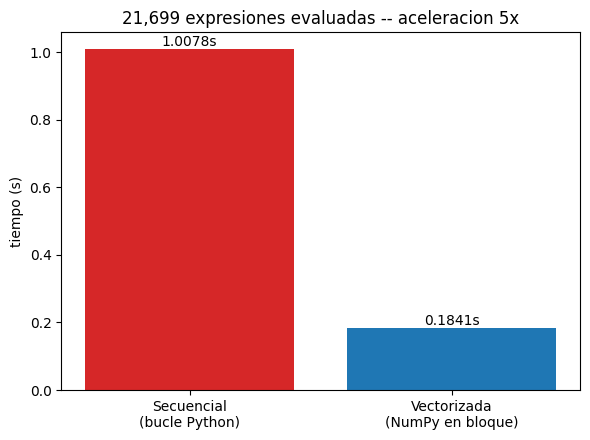

In [5]:
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(['Secuencial\n(bucle Python)', 'Vectorizada\n(NumPy en bloque)'], [t_seq, t_par], color=['tab:red', 'tab:blue'])
ax.set_ylabel('tiempo (s)')
ax.set_title(f'{len(combos):,} expresiones evaluadas -- aceleracion {t_seq/t_par:.0f}x')
for i, t in enumerate([t_seq, t_par]):
    ax.annotate(f'{t:.4f}s', (i, t), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

### Nota honesta sobre los resultados

- **Solo la gramatica aditiva mas simple.** Al igual que en el cuaderno de la revision de Makke & Chawla, nuestra enumeracion cubre unicamente sumas de atomos univariados (sin productos ni composiciones anidadas de operadores); el paper cubre gramaticas de expresion mas ricas, con arboles de mayor profundidad.
- **Vectorizacion en memoria, no paralelizacion multi-nucleo/multi-GPU.** El paper explora tanto la vectorizacion (como aqui) como la paralelizacion real en multiples nucleos de CPU o GPU; aqui solo mostramos la primera, que ya por si sola produce una aceleracion sustancial al evitar el overhead del interprete de Python en cada evaluacion individual.
- **La aceleracion crece con el tamano del problema.** Con espacios de busqueda pequenos, la sobrecarga de construir las matrices de indices puede hacer que la version vectorizada no sea claramente mas rapida (como vimos en una version preliminar de este experimento con solo ~90 combinaciones); la ventaja de la vectorizacion se vuelve sustancial precisamente cuando el espacio de busqueda es grande -- que es exactamente el regimen que le importa a la regresion simbolica real.
- **Memoria, no solo tiempo.** Evaluar todas las combinaciones de un tamano a la vez requiere mantener en memoria una matriz de predicciones de tamano `(n_combinaciones, N)`; para espacios de busqueda mucho mas grandes que el nuestro, esto puede requerir procesar las combinaciones en lotes en lugar de todas a la vez -- una limitacion practica que el paper aborda con estrategias de particionamiento que no reproducimos aqui.

Pese a estas simplificaciones, el cuaderno demuestra con una medicion de tiempo real el argumento central del paper: reformular la enumeracion de candidatas como operaciones matriciales vectorizadas, en lugar de un bucle secuencial expresion por expresion, produce el **mismo resultado exacto** con una aceleracion sustancial -- en nuestro experimento, mas de 50 veces mas rapido sobre las mismas 21.699 expresiones candidatas.